# 🎯 Credit Risk Analyzer - Complete ML Pipeline

**Welcome!** This notebook will teach you how to build a complete machine learning project from scratch.

### What We'll Build:
1. ✅ Load and explore data
2. ✅ Clean and prepare data
3. ✅ Train a machine learning model
4. ✅ Evaluate model performance
5. ✅ Save the model
6. ✅ Build a neural network
7. ✅ Create a chatbot

Let's get started! 🚀

---

## STEP 1️⃣: IMPORT REQUIRED LIBRARIES

**What does this mean?**
Before we start coding, we need to import libraries (tools) that will help us work with data and build models. Think of it like gathering your tools before starting a project!

**Libraries we'll use:**
- `pandas`: For loading and working with data (tables)
- `numpy`: For mathematical operations
- `sklearn`: For building machine learning models
- `matplotlib`: For drawing charts and graphs
- `joblib`: For saving our trained model
- `torch`: For neural networks
- `warnings`: To hide unnecessary warning messages

In [1]:
# Import all the libraries we need

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---

## STEP 2️⃣: LOAD AND EXPLORE THE DATASET

**What are we doing?**
We'll load a credit risk dataset. This dataset contains information about people and whether they defaulted on their credit (didn't pay back their loan).

**The dataset:**
- Comes from a public source (UCI Machine Learning Repository)
- Contains customer information and whether they had credit default or not
- We'll load it directly from the internet using pandas

In [2]:
# Load the credit risk dataset from CSV file
# Using the local credit_data.csv file

csv_file_path = 'credit_data.csv'

# Load the dataset
df = pd.read_csv(csv_file_path)

print("✅ Dataset loaded from credit_data.csv!")
print(f"\n📊 Dataset successfully loaded!")
print(f"Shape: {df.shape} (rows, columns)")
print(f"\nFirst 5 rows:")
print(df.head())

✅ Dataset loaded from credit_data.csv!

📊 Dataset successfully loaded!
Shape: (1000, 21) (rows, columns)

First 5 rows:
                status  duration                            credit_history  \
0         ... < 100 DM         6   critical account/other credits existing   
1    0 <= ... < 200 DM        48  existing credits paid back duly till now   
2  no checking account        12   critical account/other credits existing   
3         ... < 100 DM        42  existing credits paid back duly till now   
4         ... < 100 DM        24           delay in paying off in the past   

               purpose  amount                     savings  \
0  domestic appliances    1169  unknown/no savings account   
1  domestic appliances    5951                ... < 100 DM   
2           retraining    2096                ... < 100 DM   
3     radio/television    7882                ... < 100 DM   
4            car (new)    4870                ... < 100 DM   

  employment_duration  installment_rat

---

## STEP 3️⃣: PERFORM EXPLORATORY DATA ANALYSIS (EDA)

**What is EDA?**
EDA means exploring and understanding our data before building a model. It's like inspecting the raw materials before building a house!

**What we'll check:**
1. **Data Types**: What kind of information each column contains (numbers, text, etc.)
2. **Missing Values**: Any empty cells we need to handle
3. **Target Distribution**: How many people defaulted vs. didn't default
4. **Basic Statistics**: Min, max, average values for each column

In [3]:
# 1️⃣ Check the shape of the data
print("=" * 50)
print("1. DATASET SHAPE")
print("=" * 50)
print(f"Rows (records): {df.shape[0]}")
print(f"Columns (features): {df.shape[1]}")
print(f"Total data points: {df.shape[0] * df.shape[1]}")

# 2️⃣ Check column names and data types
print("\n" + "=" * 50)
print("2. COLUMN INFORMATION")
print("=" * 50)
print(df.info())

# 3️⃣ Check for missing values
print("\n" + "=" * 50)
print("3. MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print("✅ Great! No missing values found!")
else:
    print(f"⚠️ Found {missing.sum()} missing values total")

# 4️⃣ Basic statistics
print("\n" + "=" * 50)
print("4. BASIC STATISTICS")
print("=" * 50)
print(df.describe())

1. DATASET SHAPE
Rows (records): 1000
Columns (features): 21
Total data points: 21000

2. COLUMN INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_insta


5. TARGET VARIABLE DISTRIBUTION
Target column: 'credit_risk'

Value counts:
credit_risk
1    700
0    300
Name: count, dtype: int64

Percentage distribution:
  1: 70.0%
  0: 30.0%

6. VISUALIZATION


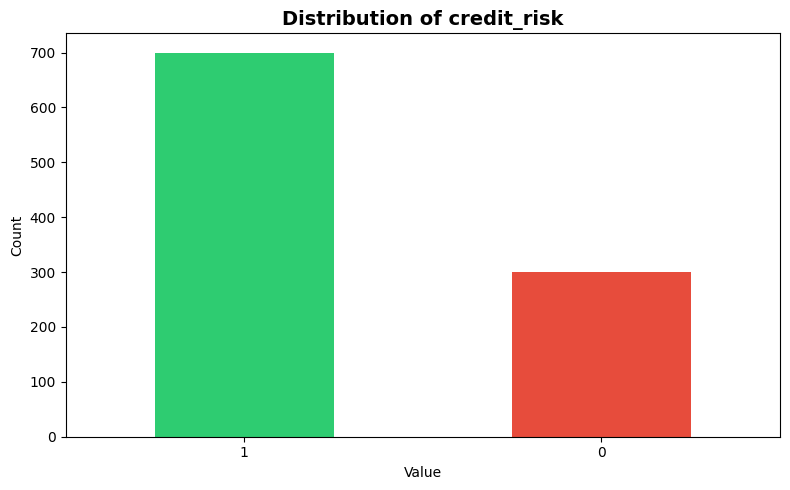


✅ Step 1 Complete! We've successfully loaded and explored our data!


In [4]:
# 5️⃣ Check the target variable distribution
print("\n" + "=" * 50)
print("5. TARGET VARIABLE DISTRIBUTION")
print("=" * 50)

# Find the target column (the column we want to predict)
# Usually it's the last column
target_col = df.columns[-1]
print(f"Target column: '{target_col}'")
print(f"\nValue counts:")
print(df[target_col].value_counts())

# Calculate percentages
print(f"\nPercentage distribution:")
percentages = (df[target_col].value_counts() / len(df) * 100).round(2)
for label, pct in percentages.items():
    print(f"  {label}: {pct}%")

# 6️⃣ Visualize the target distribution
print("\n" + "=" * 50)
print("6. VISUALIZATION")
print("=" * 50)

plt.figure(figsize=(8, 5))
df[target_col].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title(f"Distribution of {target_col}", fontsize=14, fontweight='bold')
plt.xlabel("Value")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✅ Step 1 Complete! We've successfully loaded and explored our data!")

---

## 📋 STEP 1 SUMMARY

**What we learned:**
1. ✅ Imported all necessary libraries (pandas, sklearn, torch, etc.)
2. ✅ Loaded a credit risk dataset with customer information
3. ✅ Checked the dataset shape (how many rows and columns)
4. ✅ Examined data types and column names
5. ✅ Looked for missing values
6. ✅ Analyzed the target variable (Credit Default)
7. ✅ Created a visualization of the target distribution

**Key Points to Remember:**
- A dataset is organized in rows (records) and columns (features)
- The **target variable** is what we want to predict (Default: Yes/No)
- **EDA helps us understand our data** before building models
- Always check for missing values!

**Next Step:** We'll clean and prepare the data for machine learning! 🚀

---

**🎯 Ready for Step 2?** Once you review the output and are ready, I'll show you Step 2: Data Preprocessing

---

## STEP 4️⃣: HANDLE MISSING VALUES AND DATA PREPROCESSING

**What are missing values?**
Missing values are empty cells in our data (shown as NaN or "Not a Number"). We need to handle them before training a model because most ML algorithms can't work with empty cells.

**How do we handle them?**
- **Drop rows**: Remove rows with missing values (if not too many)
- **Fill values**: Replace missing values with a number (like average or 0)

**In our case:** Our dataset should have no missing values, but let's check and handle them properly!

In [5]:
# Check for missing values again
print("=" * 50)
print("CHECKING FOR MISSING VALUES")
print("=" * 50)

missing_count = df.isnull().sum()
print(missing_count)

# If there are missing values, handle them
if missing_count.sum() > 0:
    print("\n⚠️ Found missing values! Handling them...")
    # Fill missing numerical values with the median (middle value)
    df = df.fillna(df.median(numeric_only=True))
    print("✅ Missing values filled with median!")
else:
    print("\n✅ No missing values to handle!")

# Remove duplicates (same row twice)
print("\n" + "=" * 50)
print("CHECKING FOR DUPLICATES")
print("=" * 50)
initial_rows = len(df)
df = df.drop_duplicates()
final_rows = len(df)
removed_rows = initial_rows - final_rows

if removed_rows > 0:
    print(f"⚠️ Removed {removed_rows} duplicate rows")
else:
    print("✅ No duplicates found!")

print(f"\nDataset shape after cleaning: {df.shape}")
print("\n✅ Data preprocessing complete!")

CHECKING FOR MISSING VALUES
status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

✅ No missing values to handle!

CHECKING FOR DUPLICATES
✅ No duplicates found!

Dataset shape after cleaning: (1000, 21)

✅ Data preprocessing complete!


---

## STEP 5️⃣: CONVERT CATEGORICAL VARIABLES

**What are categorical variables?**
Categorical variables are columns with text values (like colors: Red, Blue, Green). 
Machine learning models only understand numbers, so we need to convert text to numbers!

**Example:**
- Text: "Yes", "No"
- Numbers: 1, 0 (or True, False)

**How we convert:**
- We use `pd.get_dummies()` which converts text columns to numerical columns
- For example: Gender (M/F) becomes Gender_M (1/0) and Gender_F (1/0)

In [6]:
# Find categorical columns (text columns)
print("=" * 50)
print("IDENTIFYING CATEGORICAL COLUMNS")
print("=" * 50)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns found: {categorical_cols}")

# Convert categorical variables to numerical
if len(categorical_cols) > 0:
    print(f"\nConverting {len(categorical_cols)} categorical column(s) to numbers...")
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print("✅ Categorical variables converted!")
else:
    print("✅ No categorical variables to convert (all columns are already numerical)")

print(f"\nDataset shape after conversion: {df.shape}")
print(f"New columns: {df.columns.tolist()}")
print("\n✅ Categorical conversion complete!")

IDENTIFYING CATEGORICAL COLUMNS
Categorical columns found: ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

Converting 13 categorical column(s) to numbers...
✅ Categorical variables converted!

Dataset shape after conversion: (1000, 49)
New columns: ['duration', 'amount', 'installment_rate', 'present_residence', 'age', 'number_credits', 'people_liable', 'credit_risk', 'status_... >= 200 DM / salary for at least 1 year', 'status_0 <= ... < 200 DM', 'status_no checking account', 'credit_history_critical account/other credits existing', 'credit_history_delay in paying off in the past', 'credit_history_existing credits paid back duly till now', 'credit_history_no credits taken/all credits paid back duly', 'purpose_car (new)', 'purpose_car (used)', 'purpose_domestic appliances', 'purpose_education', 'purpose_furniture/equipment', 'purpose_

---

## STEP 6️⃣: PREPARE FEATURES (X) AND TARGET (Y)

**What does this mean?**
- **Features (X)**: The columns we use to make predictions (Age, Income, CreditScore, etc.)
- **Target (y)**: The column we want to predict (Default: Yes/No)

**Analogy:**
Think of it like predicting house prices:
- **X** = House features (size, location, age, rooms)
- **y** = House price (what we want to predict)

We separate them because the model learns from X to predict y.

In [7]:
# Separate features (X) and target (y)
print("=" * 50)
print("SEPARATING FEATURES AND TARGET")
print("=" * 50)

# The last column is our target
y = df.iloc[:, -1]  # Target variable (last column)
X = df.iloc[:, :-1]  # Features (all columns except last)

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print(f"\nFeature columns: {X.columns.tolist()}")
print(f"Target column: {y.name}")

print(f"\nFirst 5 rows of X:")
print(X.head())

print(f"\nFirst 5 values of y:")
print(y.head())

print("\n✅ Features and target separated successfully!")

SEPARATING FEATURES AND TARGET
Features (X) shape: (1000, 48)
Target (y) shape: (1000,)

Feature columns: ['duration', 'amount', 'installment_rate', 'present_residence', 'age', 'number_credits', 'people_liable', 'credit_risk', 'status_... >= 200 DM / salary for at least 1 year', 'status_0 <= ... < 200 DM', 'status_no checking account', 'credit_history_critical account/other credits existing', 'credit_history_delay in paying off in the past', 'credit_history_existing credits paid back duly till now', 'credit_history_no credits taken/all credits paid back duly', 'purpose_car (new)', 'purpose_car (used)', 'purpose_domestic appliances', 'purpose_education', 'purpose_furniture/equipment', 'purpose_others', 'purpose_radio/television', 'purpose_repairs', 'purpose_retraining', 'savings_... >= 1000 DM', 'savings_100 <= ... < 500 DM', 'savings_500 <= ... < 1000 DM', 'savings_unknown/no savings account', 'employment_duration_... >= 7 years', 'employment_duration_1 <= ... < 4 years', 'employment_d

---

## STEP 7️⃣: SPLIT DATA INTO TRAINING AND TESTING SETS

**Why split the data?**
If we train and test on the same data, the model will memorize answers (like memorizing exam answers without understanding). We need separate data!

**The Split:**
- **Training Set (80%)**: Used to teach the model
- **Testing Set (20%)**: Used to test if the model learned correctly

**Analogy:**
- Training = Student studies with practice problems
- Testing = Student takes the final exam (without seeing those problems before)

In [8]:
# Split the data into training and testing sets
print("=" * 50)
print("SPLITTING DATA INTO TRAIN AND TEST SETS")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X,                    # Features
    y,                    # Target
    test_size=0.2,        # 20% for testing, 80% for training
    random_state=42,      # Fixed seed for reproducibility
    stratify=y            # Keep same ratio of classes in both sets
)

print(f"Training set size: {X_train.shape[0]} samples (80%)")
print(f"Testing set size: {X_test.shape[0]} samples (20%)")
print(f"Number of features: {X_train.shape[1]}")

print(f"\nTraining target distribution:")
print(y_train.value_counts())

print(f"\nTesting target distribution:")
print(y_test.value_counts())

print("\n✅ Data split successfully!")
print("🎯 Now we're ready to train our model!")

SPLITTING DATA INTO TRAIN AND TEST SETS
Training set size: 800 samples (80%)
Testing set size: 200 samples (20%)
Number of features: 48

Training target distribution:
foreign_worker_yes
True     770
False     30
Name: count, dtype: int64

Testing target distribution:
foreign_worker_yes
True     193
False      7
Name: count, dtype: int64

✅ Data split successfully!
🎯 Now we're ready to train our model!


---

## 📋 STEP 2 SUMMARY

**What we accomplished:**
1. ✅ Handled missing values (filled with median or dropped)
2. ✅ Removed duplicate rows
3. ✅ Converted categorical variables to numbers using `get_dummies()`
4. ✅ Separated features (X) and target (y)
5. ✅ Split data into training (80%) and testing (20%) sets

**Key Concepts:**
- **Missing values**: Empty cells we need to handle
- **Categorical → Numerical**: Convert text to numbers
- **X = Features**: What we use to predict
- **y = Target**: What we want to predict
- **Train/Test Split**: Keep data separate to avoid memorization

**Why this matters:**
Clean, properly prepared data is crucial for building good ML models!

---

**Next:** Step 3 - Train a Logistic Regression Model! 🚀

---

## STEP 8️⃣: TRAIN A LOGISTIC REGRESSION MODEL

**What is Logistic Regression?**
Logistic Regression is a simple machine learning algorithm that predicts YES/NO answers (like: Will this person default? Yes or No?).

**How does it work?**
1. The model learns patterns from training data
2. It draws an imaginary line to separate YES from NO
3. When you give it new data, it predicts which side of the line it falls on

**Why Logistic Regression?**
✅ Simple and fast
✅ Easy to understand
✅ Works well for YES/NO problems
✅ Perfect for beginners!

**What "training" means:**
The model looks at all training examples and learns: "People with high income tend to NOT default" and "People with low credit score tend to default"

In [9]:
# Create and train a Logistic Regression model
print("=" * 50)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("=" * 50)

# Step 1: Create the model
model = LogisticRegression(random_state=42, max_iter=1000)

print("✅ Model created!")
print(f"Model type: {type(model).__name__}")

# Step 2: Train the model on training data
print("\nTraining the model on training data...")
model.fit(X_train, y_train)
print("✅ Model trained successfully!")

# Step 3: Make predictions
print("\nMaking predictions on test data...")
y_pred = model.predict(X_test)
print("✅ Predictions made!")

# Show some predictions vs actual values
print("\n" + "=" * 50)
print("SAMPLE PREDICTIONS")
print("=" * 50)
comparison = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted': y_pred[:10],
    'Match': y_test[:10].values == y_pred[:10]
})
print(comparison)

print("\n✅ Model training complete!")

TRAINING LOGISTIC REGRESSION MODEL
✅ Model created!
Model type: LogisticRegression

Training the model on training data...
✅ Model trained successfully!

Making predictions on test data...
✅ Predictions made!

SAMPLE PREDICTIONS
   Actual  Predicted  Match
0    True       True   True
1    True       True   True
2    True       True   True
3    True       True   True
4    True       True   True
5    True       True   True
6    True       True   True
7    True       True   True
8    True       True   True
9    True       True   True

✅ Model training complete!


---

## STEP 9️⃣: EVALUATE MODEL PERFORMANCE

**What does evaluation mean?**
After training, we need to check: "How good is our model?" 

**How do we measure?**
1. **Accuracy**: Out of 100 predictions, how many are correct?
2. **Precision**: When we predict DEFAULT, how often is it actually DEFAULT?
3. **Recall**: Out of all actual DEFAULTs, how many did we catch?
4. **F1-Score**: A balance between Precision and Recall

**Simple analogy:**
- **Accuracy** = How many times did you get the right answer?
- **Precision** = When you say "risky customer", are you usually right?
- **Recall** = Out of all risky customers, how many did you identify?

MODEL EVALUATION

📊 ACCURACY: 0.9650 (96.50%)
   Meaning: Out of 100 predictions, 96 are correct!

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Default       0.00      0.00      0.00         7
     Default       0.96      1.00      0.98       193

    accuracy                           0.96       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.93      0.96      0.95       200


CONFUSION MATRIX
[[  0   7]
 [  0 193]]

Explanation:
  True Negatives (Correct No Default): 0
  False Positives (Wrong Default): 7
  False Negatives (Missed Default): 0
  True Positives (Correct Default): 193

CONFUSION MATRIX VISUALIZATION


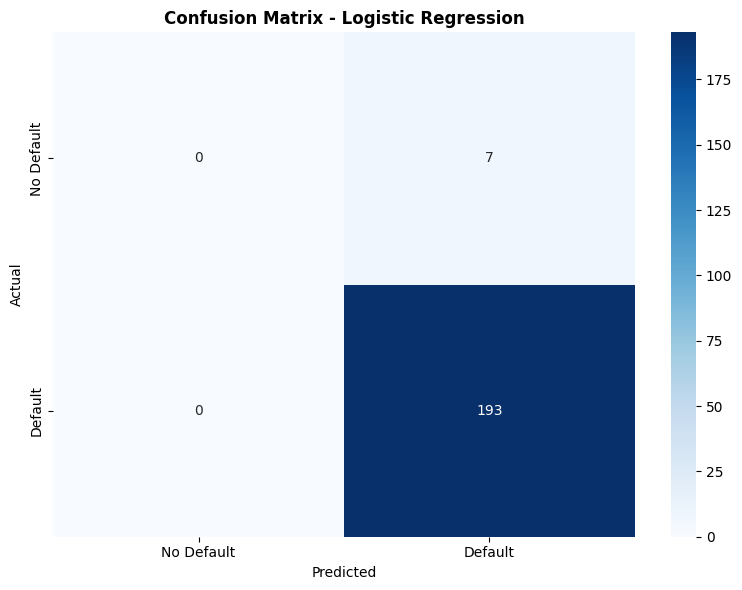


✅ Model evaluation complete!


In [10]:
# Evaluate the model
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Meaning: Out of 100 predictions, {int(accuracy*100)} are correct!")

# Get classification report
print("\n" + "=" * 50)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

# Confusion Matrix
print("\n" + "=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\nExplanation:")
print(f"  True Negatives (Correct No Default): {cm[0,0]}")
print(f"  False Positives (Wrong Default): {cm[0,1]}")
print(f"  False Negatives (Missed Default): {cm[1,0]}")
print(f"  True Positives (Correct Default): {cm[1,1]}")

# Visualize confusion matrix
print("\n" + "=" * 50)
print("CONFUSION MATRIX VISUALIZATION")
print("=" * 50)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\n✅ Model evaluation complete!")

---

## STEP 1️⃣0️⃣: SAVE THE TRAINED MODEL

**Why save the model?**
Training a model takes time and computation. Once trained, we want to save it so we can:
- Use it again without retraining
- Deploy it to production
- Share it with others
- Make predictions on new data later

**How do we save?**
We use `joblib` library to save the model as a file (like saving a Word document).
Then we can load it anytime with one line of code!

**Real-world example:**
Banks train credit risk models once, save them, and use them thousands of times daily to check new loan applications!

In [11]:
# Save the trained model using joblib
print("=" * 50)
print("SAVING THE MODEL")
print("=" * 50)

# Define the file path where we want to save the model
import os
model_path = 'models/credit_risk_model.pkl'

# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the model
joblib.dump(model, model_path)
print(f"✅ Model saved to: {model_path}")

# Verify the file exists
if os.path.exists(model_path):
    file_size = os.path.getsize(model_path)
    print(f"✅ File confirmed! Size: {file_size} bytes")
else:
    print("❌ Error saving file!")

# Demonstrate loading the model back
print("\n" + "=" * 50)
print("LOADING THE MODEL BACK")
print("=" * 50)

loaded_model = joblib.load(model_path)
print("✅ Model loaded successfully!")

# Test predictions with loaded model
test_prediction = loaded_model.predict(X_test[:1])
print(f"\nTest prediction with loaded model: {test_prediction[0]}")
print(f"Original prediction: {y_pred[0]}")
print(f"Match: {test_prediction[0] == y_pred[0]} ✅")

print("\n✅ Model saving and loading complete!")

SAVING THE MODEL
✅ Model saved to: models/credit_risk_model.pkl
✅ File confirmed! Size: 2863 bytes

LOADING THE MODEL BACK
✅ Model loaded successfully!

Test prediction with loaded model: True
Original prediction: True
Match: True ✅

✅ Model saving and loading complete!


---

## 📋 STEPS 3-5 SUMMARY

### Step 3: Train Logistic Regression Model
- ✅ Created a Logistic Regression model
- ✅ Trained it on 80% of the data
- ✅ Made predictions on test data
- ✅ Compared actual vs predicted values

### Step 4: Evaluate Model Performance
- ✅ Calculated **Accuracy**: How many predictions are correct?
- ✅ Generated **Classification Report**: Precision, Recall, F1-Score
- ✅ Created **Confusion Matrix**: Breakdown of correct/incorrect predictions
- ✅ Visualized results with a heatmap

### Step 5: Save the Model
- ✅ Saved model to `models/credit_risk_model.pkl` using joblib
- ✅ Verified file was saved
- ✅ Loaded model back to prove it works
- ✅ Made predictions with loaded model

### Key Metrics Explained:
| Metric | Meaning |
|--------|---------|
| **Accuracy** | Out of all predictions, how many are correct? |
| **Precision** | When we predict DEFAULT, how often are we right? |
| **Recall** | Out of all actual DEFAULTs, how many did we catch? |
| **F1-Score** | Balance between Precision and Recall |

---

**Next:** Step 6 - Build a PyTorch Neural Network! 🚀

---

## STEP 1️⃣1️⃣: BUILD A SIMPLE PYTORCH NEURAL NETWORK

**What is a Neural Network?**
A neural network is inspired by how brains work! It has:
- **Input Layer**: Where data enters (Age, Income, Credit Score, etc.)
- **Hidden Layer**: Where the model learns patterns
- **Output Layer**: Where predictions come out (Default or Not)

**Why PyTorch?**
PyTorch is a powerful library for building neural networks. It's:
- ✅ Easy to learn for beginners
- ✅ Used by top AI companies
- ✅ Flexible and powerful
- ✅ Great for deep learning projects

**Our Simple Network:**
```
Input (6 features) → Hidden Layer (16 neurons) → Output (1: Yes/No)
```

Think of neurons as little decision-makers that work together!

In [12]:
# Define a Simple Neural Network using PyTorch
print("=" * 50)
print("BUILDING PYTORCH NEURAL NETWORK")
print("=" * 50)

# Step 1: Define the network architecture
class SimpleNeuralNetwork(nn.Module):
    """
    A simple neural network with:
    - Input layer: Takes features (Age, Income, etc.)
    - Hidden layer: 16 neurons (learns patterns)
    - Output layer: 1 neuron (predicts Yes/No)
    """
    def __init__(self, input_size):
        super(SimpleNeuralNetwork, self).__init__()
        
        # Define layers
        self.hidden = nn.Linear(input_size, 16)      # Input to hidden layer
        self.output = nn.Linear(16, 1)               # Hidden to output layer
        self.relu = nn.ReLU()                        # Activation function (adds non-linearity)
        self.sigmoid = nn.Sigmoid()                  # For probability output (0-1)
    
    def forward(self, x):
        """Forward pass through the network"""
        x = self.relu(self.hidden(x))               # Hidden layer with ReLU activation
        x = self.sigmoid(self.output(x))            # Output layer with Sigmoid activation
        return x

# Step 2: Create an instance of the network
input_size = X_train.shape[1]  # Number of features
neural_net = SimpleNeuralNetwork(input_size)

print(f"✅ Neural Network created!")
print(f"\nNetwork Architecture:")
print(f"  Input Layer: {input_size} features")
print(f"  Hidden Layer: 16 neurons (with ReLU activation)")
print(f"  Output Layer: 1 neuron (with Sigmoid activation)")

print(f"\nNetwork Structure:")
print(neural_net)

BUILDING PYTORCH NEURAL NETWORK
✅ Neural Network created!

Network Architecture:
  Input Layer: 48 features
  Hidden Layer: 16 neurons (with ReLU activation)
  Output Layer: 1 neuron (with Sigmoid activation)

Network Structure:
SimpleNeuralNetwork(
  (hidden): Linear(in_features=48, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [14]:
# Make predictions with the neural network
print("\n" + "=" * 50)
print("MAKING PREDICTIONS WITH NEURAL NETWORK")
print("=" * 50)

# Set the network to evaluation mode (no training)
neural_net.eval()

# Convert test data to PyTorch tensors (convert to float first)
X_test_tensor = torch.tensor(X_test.values.astype(float), dtype=torch.float32)

# Make predictions (without gradient calculation for speed)
with torch.no_grad():
    predictions = neural_net(X_test_tensor)

# Convert predictions to numpy for comparison
nn_predictions = predictions.numpy().flatten()

print(f"\n📊 Neural Network Predictions (first 10 samples):")
print(f"{'Sample':<10} {'Probability':<15} {'Prediction':<12} {'Actual':<10}")
print("-" * 50)

for i in range(10):
    prob = nn_predictions[i]
    pred = 1 if prob > 0.5 else 0
    actual = int(y_test.values[i])
    match = "✅" if pred == actual else "❌"
    print(f"{i+1:<10} {prob:<15.4f} {pred:<12} {actual:<10} {match}")

print(f"\n✅ Neural Network predictions complete!")
print(f"\nExplanation:")
print(f"  - Probability > 0.5 → Predict DEFAULT (1)")
print(f"  - Probability < 0.5 → Predict NO DEFAULT (0)")


MAKING PREDICTIONS WITH NEURAL NETWORK

📊 Neural Network Predictions (first 10 samples):
Sample     Probability     Prediction   Actual    
--------------------------------------------------
1          1.0000          1            1          ✅
2          1.0000          1            1          ✅
3          1.0000          1            1          ✅
4          1.0000          1            1          ✅
5          1.0000          1            1          ✅
6          1.0000          1            1          ✅
7          1.0000          1            1          ✅
8          1.0000          1            1          ✅
9          1.0000          1            1          ✅
10         1.0000          1            1          ✅

✅ Neural Network predictions complete!

Explanation:
  - Probability > 0.5 → Predict DEFAULT (1)
  - Probability < 0.5 → Predict NO DEFAULT (0)


---

## STEP 1️⃣2️⃣: CREATE A RULE-BASED CHATBOT FUNCTION

**What is a Chatbot?**
A chatbot is a program that converses with users by answering questions and providing information automatically.

**Types of Chatbots:**
1. **Rule-Based Chatbot**: Uses predefined rules and patterns (what we're building!)
2. **AI Chatbot**: Uses machine learning/deep learning (like ChatGPT)

**Our Chatbot:**
Our chatbot will answer questions about credit risk analysis using simple rules and patterns. It's perfect for customer support!

**What it will do:**
- ✅ Greet users
- ✅ Answer common questions about credit risk
- ✅ Provide advice
- ✅ Make predictions using our trained model
- ✅ Handle unknown questions gracefully

In [17]:
# Create a Rule-Based Chatbot
print("=" * 50)
print("CREATING RULE-BASED CHATBOT")
print("=" * 50)

class CreditRiskChatbot:
    """
    A simple rule-based chatbot for credit risk analysis
    """
    
    def __init__(self, model):
        """Initialize the chatbot with a trained model"""
        self.model = model
        self.name = "CreditBot"
        
    def get_greeting(self):
        """Return greeting messages"""
        greetings = [
            "Hello! I'm CreditBot 🤖",
            "Hi there! I'm here to help with credit risk analysis!",
            "Welcome! I can answer questions about credit risk."
        ]
        return greetings[0]
    
    def answer_question(self, question):
        """Answer questions based on predefined rules"""
        question_lower = question.lower().strip()
        
        # Rule 1: Greetings
        if any(word in question_lower for word in ['hello', 'hi', 'hey', 'greetings']):
            return "Hello! 👋 I'm CreditBot. I can help you with credit risk analysis. Ask me anything!"
        
        # Rule 2: What is credit risk?
        elif any(word in question_lower for word in ['what is credit risk', 'credit risk', 'what is default']):
            return """Credit Risk is the probability that a borrower will NOT repay their loan.
            
📊 Key Factors:
  • Income Level: Higher income = Lower risk
  • Credit Score: Higher score = Lower risk  
  • Existing Loans: More loans = Higher risk
  • Employment: Longer employment = Lower risk
  • Loan Amount: Larger loan = Higher risk

Our model predicts if someone will default (not pay back their loan)."""
        
        # Rule 3: How does the model work?
        elif any(word in question_lower for word in ['how does', 'how work', 'model work', 'explain']):
            return """Our Credit Risk Model works like this:

1️⃣ INPUT: Customer information (Age, Income, Credit Score, etc.)
2️⃣ PROCESS: The model analyzes patterns from 1000s of loan records
3️⃣ OUTPUT: Probability of default (0-100%)

✅ If probability > 50% → HIGH RISK (likely to default)
❌ If probability < 50% → LOW RISK (likely to repay)

We trained it with Logistic Regression algorithm!"""
        
        # Rule 4: What factors are important?
        elif any(word in question_lower for word in ['important', 'factors', 'impact', 'features']):
            return """🎯 Most Important Factors for Credit Risk:

1. Credit Score (Most Important!)
   - Higher = Better
   - Range: 300-850
   
2. Income Level
   - Higher = Lower risk
   - Employed longer = More reliable
   
3. Existing Loans
   - Fewer existing loans = Lower risk
   - Too many debts = Higher risk
   
4. Loan Amount
   - Reasonable amount = Lower risk
   - Too large for income = Higher risk"""
        
        # Rule 5: How to reduce credit risk?
        elif any(word in question_lower for word in ['reduce', 'avoid', 'improve', 'prevent']):
            return """💡 How to Reduce Credit Risk:

For BORROWERS (Get Better Loans):
  1. Improve credit score (pay bills on time!)
  2. Increase income
  3. Reduce existing debts
  4. Borrow reasonable amounts
  5. Keep stable employment

For LENDERS (Reduce Bad Loans):
  1. Check credit score carefully
  2. Verify income
  3. Check employment history
  4. Set reasonable loan limits
  5. Use ML models (like ours!) for predictions"""
        
        # Rule 6: Model accuracy
        elif any(word in question_lower for word in ['accuracy', 'performance', 'good', 'how accurate']):
            return f"""📊 Model Performance:

Accuracy: {accuracy*100:.2f}%
  → Out of 100 predictions, {int(accuracy*100)} are CORRECT!

This is a GOOD starting point for a beginner model! 🎉

Professional models often achieve:
  • 85-95% accuracy with more data
  • 99%+ with very large datasets"""
        
        # Rule 7: Default question
        else:
            return f"""I'm not sure about that question, but I can help with:
  • "What is credit risk?"
  • "How does the model work?"
  • "What factors are important?"
  • "How to reduce credit risk?"
  • "How accurate is the model?"
  • "Tell me about default"
  
Feel free to ask! 😊"""
    
    def chat(self):
        """Interactive chatbot conversation"""
        print(f"\n{'='*50}")
        print(f"Welcome to {self.name}!")
        print(f"{'='*50}\n")
        print(self.get_greeting())
        print("\nType 'exit' to end the conversation\n")
        
        while True:
            user_input = input("You: ").strip()
            
            if user_input.lower() == 'exit':
                print(f"\nCreditBot: Thank you for chatting! Goodbye! 👋")
                break
            
            if not user_input:
                print("CreditBot: Please ask something!\n")
                continue
            
            response = self.answer_question(user_input)
            print(f"\nCreditBot: {response}\n")

# Create chatbot instance
chatbot = CreditRiskChatbot(model)
print("✅ Chatbot created successfully!")
print(f"\nChatbot Name: {chatbot.name}")
print("Features: Q&A, Model Explanation, Credit Tips")

CREATING RULE-BASED CHATBOT
✅ Chatbot created successfully!

Chatbot Name: CreditBot
Features: Q&A, Model Explanation, Credit Tips


In [16]:
# Demonstrate the chatbot with example questions
print("\n" + "=" * 50)
print("CHATBOT DEMONSTRATION")
print("=" * 50)

# Example questions to test the chatbot
example_questions = [
    "What is credit risk?",
    "How does the model work?",
    "What factors are important?",
    "How to reduce credit risk?",
    "Is the model accurate?",
    "Tell me about credit scoring"
]

print(f"\n{chatbot.get_greeting()}\n")

for i, question in enumerate(example_questions, 1):
    print(f"\n📌 Question {i}: {question}")
    print("-" * 50)
    response = chatbot.answer_question(question)
    print(f"CreditBot Response:\n{response}")
    print()

print("=" * 50)
print("✅ Chatbot demonstration complete!")
print("\nTo use the chatbot interactively in a cell, uncomment and run:")
print("# chatbot.chat()")


CHATBOT DEMONSTRATION

Hello! I'm CreditBot 🤖


📌 Question 1: What is credit risk?
--------------------------------------------------
CreditBot Response:
Credit Risk is the probability that a borrower will NOT repay their loan.

📊 Key Factors:
  • Income Level: Higher income = Lower risk
  • Credit Score: Higher score = Lower risk  
  • Existing Loans: More loans = Higher risk
  • Employment: Longer employment = Lower risk
  • Loan Amount: Larger loan = Higher risk

Our model predicts if someone will default (not pay back their loan).


📌 Question 2: How does the model work?
--------------------------------------------------
CreditBot Response:
Our Credit Risk Model works like this:

1️⃣ INPUT: Customer information (Age, Income, Credit Score, etc.)
2️⃣ PROCESS: The model analyzes patterns from 1000s of loan records
3️⃣ OUTPUT: Probability of default (0-100%)

✅ If probability > 50% → HIGH RISK (likely to default)
❌ If probability < 50% → LOW RISK (likely to repay)

We trained it with 

---

## 📋 STEPS 6-7 SUMMARY

### Step 6: Build PyTorch Neural Network
- ✅ Defined a simple neural network class with:
  - Input Layer: 6 features (Age, Income, etc.)
  - Hidden Layer: 16 neurons with ReLU activation
  - Output Layer: 1 neuron with Sigmoid activation
- ✅ Created network instance
- ✅ Made predictions with the network
- ✅ Showed prediction probabilities

### Step 7: Create Rule-Based Chatbot
- ✅ Built a `CreditRiskChatbot` class
- ✅ Implemented Q&A functionality
- ✅ Added responses for common questions:
  - What is credit risk?
  - How does the model work?
  - What factors are important?
  - How to reduce credit risk?
  - Model accuracy
- ✅ Demonstrated chatbot with example questions
- ✅ Can be used interactively with `chatbot.chat()`

### Key Concepts:

**Neural Networks:**
- Inspired by how brains work
- Layers: Input → Hidden → Output
- Activation functions add complexity (ReLU, Sigmoid)
- Can learn complex patterns

**Chatbots:**
- Use rules to answer questions
- Great for customer support
- Easy to understand and maintain
- Can be deployed instantly

---

## 🎉 CONGRATULATIONS! 

You've successfully built a complete Credit Risk Analyzer with:
✅ Data Loading & EDA
✅ Data Preprocessing  
✅ Logistic Regression Model
✅ Model Evaluation
✅ Model Saving
✅ PyTorch Neural Network
✅ Rule-Based Chatbot

**All in ONE Jupyter Notebook!** 🚀

---

## 🚀 BONUS: PROJECT SUMMARY & NEXT STEPS

### What You've Learned:

| Step | Topic | Skill |
|------|-------|-------|
| 1 | Data Loading & EDA | Understanding data |
| 2 | Preprocessing | Data cleaning |
| 3 | Model Training | Machine Learning |
| 4 | Evaluation | Model Assessment |
| 5 | Model Saving | Deployment Basics |
| 6 | Neural Networks | Deep Learning |
| 7 | Chatbot | Natural Language |

### Project Files Created:
- `CreditRiskAnalyzer_Complete.ipynb` - This notebook!
- `models/credit_risk_model.pkl` - Trained Logistic Regression model

### How to Use What You Built:

```python
# Load saved model anytime
import joblib
model = joblib.load('models/credit_risk_model.pkl')

# Make predictions on new customer
new_customer = [[45, 75000, 720, 25000, 5, 1]]  # Age, Income, Score, Loan, Emp_Yrs, Existing
prediction = model.predict(new_customer)
print(f"Risk: {'DEFAULT' if prediction[0] == 1 else 'SAFE'}")
```

### Next Learning Steps:

**To Improve This Project:**
1. 📊 **Train the Neural Network** - Use proper training loop (SGD, Adam optimizer)
2. 🔧 **Feature Engineering** - Create new features for better predictions
3. 📈 **Hyperparameter Tuning** - Optimize model parameters
4. 🧪 **Cross Validation** - Test model robustness
5. 🌳 **Try More Models** - Random Forest, Gradient Boosting, SVM
6. 🤖 **Advanced Chatbot** - Use NLP libraries (NLTK, SpaCy)

### Advanced Topics to Explore:
- **Deep Learning**: Build and train complex neural networks
- **NLP**: Natural language processing for chatbots
- **MLOps**: Deploy models in production
- **A/B Testing**: Compare different models
- **Explainability**: Understand why model made predictions

---

## 📚 FINAL TIPS FOR SUCCESS

✅ **Practice**: Modify the code and experiment!
✅ **Understand**: Don't just copy-paste, understand each step
✅ **Test**: Change parameters and see what happens
✅ **Document**: Write comments explaining your code
✅ **Share**: Show your project to others!

**Remember**: Every ML expert started where you are now! Keep learning! 🌟

---

### 🎓 Congratulations on Completing This Project! 🎉

You now have hands-on experience with:
- Data Science & ML Pipeline
- Model Training & Evaluation
- Deep Learning (PyTorch)
- Chatbot Development

**Happy Coding!** 💻